# Pipeline-Rundgang: von den Rohdaten zur Baseline

**Autor:** jd · **Datum:** 2026-10-06

**Ziel:** Zeigen, was die gemeinsame Pipeline macht und wie man mit ihr in wenigen Zeilen ein
Modell trainiert, bewertet und in MLflow protokolliert – am Beispiel der Baseline.
Hintergrund: `docs/daten/pipeline.md` · Fehleranalyse der Baseline: `01_jd_baseline.ipynb`.

## Überblick

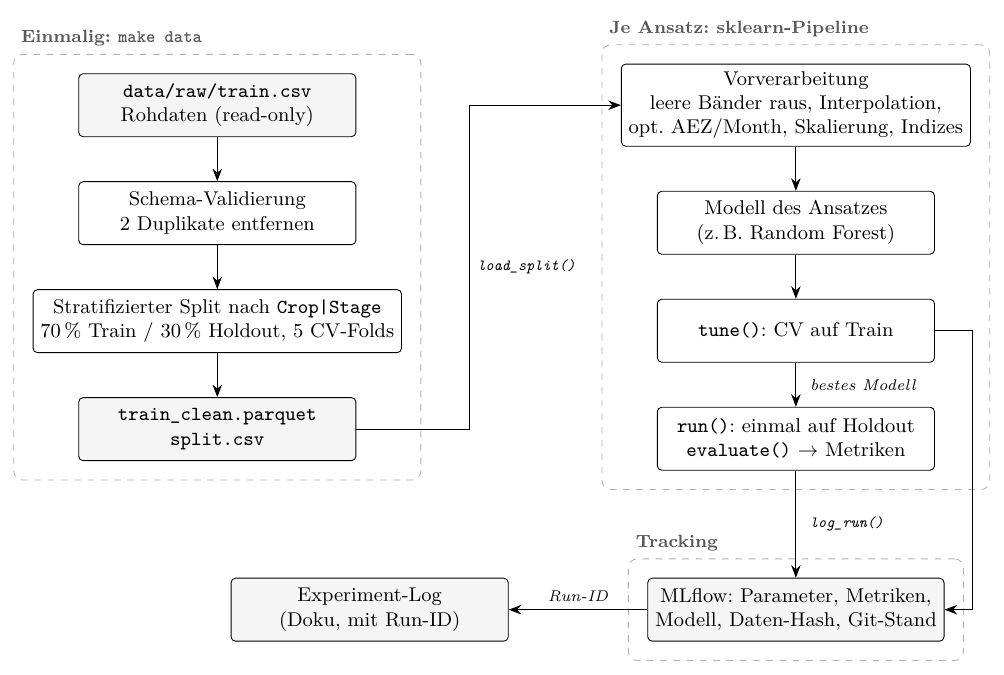

- **Einmalig (`make data`):** Rohdaten prüfen, Duplikate entfernen, fest in Train und Holdout
  teilen – bei allen identisch.
- **Je Ansatz:** Vorverarbeitung + Modell bilden eine sklearn-Pipeline, die nur auf Train
  gelernt wird. `tune()` wählt Hyperparameter per Cross-Validation, `run()` bewertet **einmal**
  auf dem Holdout.
- **Tracking:** Jeder Lauf landet mit Parametern, Metriken, Modell und Git-Stand in MLflow.

| Schritt | Funktion |
| --- | --- |
| Artefakte erzeugen / laden | `build_artifacts()` (= `make data`), `load_split()`, `load_folds()` |
| Vorverarbeitung | `build_preprocessor(PreprocessingConfig(...))` |
| Hyperparameter suchen | `tune(model, TuneConfig(...))` |
| Trainieren + bewerten + tracken | `run(model, RunConfig(...))` → `evaluate()` → MLflow |

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import mlflow.sklearn
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

from awp2.config import MLFLOW_TRACKING_URI, SEED
from awp2.data import (
    StaleArtifactsError,
    band_columns,
    build_artifacts,
    combined_label,
    load_dataset,
    load_folds,
    load_split,
    load_test,
    load_train,
    wavelengths,
)
from awp2.evaluation import plot_confusion_matrices
from awp2.experiment import RunConfig, TuneConfig, run, tune
from awp2.plots import plot_metric_comparison, plot_tuning_candidates
from awp2.preprocessing import PreprocessingConfig, build_preprocessor

# Own MLflow experiment, so tutorial runs do not mix with the real runs in "crop-stage".
EXPERIMENT = "pipeline-tutorial"

## 1 · Artefakte: bereinigte Daten und fester Split

`make data` schreibt `data/interim/train_clean.parquet` und `data/processed/split.csv`. Die
Zelle holt das nach, falls die Dateien fehlen oder nicht mehr zu den Rohdaten passen.

In [ ]:
try:
    load_split()
except StaleArtifactsError:
    build_artifacts()

print(f"Rohdaten:  {len(load_train())} Zeilen")
print(f"Bereinigt: {len(load_dataset().X)} Zeilen (exakte Duplikate entfernt)")

## 2 · Split: 70 % Train, 30 % Holdout, 5 CV-Folds

Der **Holdout** bleibt bis zur abschließenden Bewertung unberührt; getunt wird nur über die
fünf Folds im Train-Teil. Stratifiziert ist nach dem Paar `Crop|Stage`, damit auch seltene
Paare in beiden Teilen vorkommen.

In [ ]:
split = load_split()
folds = load_folds()

sizes = {"Train": len(split.X_train), "Holdout": len(split.X_val)}
sizes |= {f"Fold {i} (CV-Prüfteil)": len(fold.val) for i, fold in enumerate(folds)}
pd.Series(sizes, name="Zeilen").to_frame()

In [ ]:
pairs = pd.DataFrame(
    {
        "Train": combined_label(split.y_train).value_counts(),
        "Holdout": combined_label(split.y_val).value_counts(),
    }
)
shares = pairs / pairs.sum()
print(f"Größte Abweichung der Klassenanteile: {(shares.Train - shares.Holdout).abs().max():.2%}")
pairs.sort_values("Train").head(5)  # seltenste Paare

## 3 · Vorverarbeitung

Die Optionen stehen in `PreprocessingConfig`; ein neuer Schritt wird dort ein neues Feld.

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.Series(
    {name: field.description for name, field in PreprocessingConfig.model_fields.items()},
    name="Wirkung",
).to_frame()

Zur Veranschaulichung wird die Vorverarbeitung hier einzeln gelernt – in `run()` und
`tune()` passiert das automatisch innerhalb der Pipeline und nur auf dem jeweiligen Train-Teil.

In [ ]:
preprocessor = build_preprocessor(PreprocessingConfig())
X_train_pre = preprocessor.fit_transform(split.X_train)

pd.DataFrame(
    {
        "Spalten": [split.X_train.shape[1], X_train_pre.shape[1]],
        "Bänder": [len(band_columns(split.X_train)), len(band_columns(X_train_pre))],
        "Fehlende Werte": [split.X_train.isna().sum().sum(), X_train_pre.isna().sum().sum()],
    },
    index=["vorher", "nachher"],
)

Ein Spektrum mit Lücke, vorher und nachher: Die grau hinterlegten Bereiche sind komplett leere
Bänder (Wasserabsorption, Sensorränder) und werden entfernt; einzelne Lücken werden entlang der
Wellenlänge aus den Nachbarbändern interpoliert.

In [ ]:
raw_bands, kept_bands = band_columns(split.X_train), band_columns(X_train_pre)
gaps = split.X_train[kept_bands].isna()
row = gaps.sum(axis=1).idxmax()

raw = split.X_train.loc[row, raw_bands].set_axis(wavelengths(split.X_train))
# Reindexing onto all bands breaks the line where bands were removed.
processed = X_train_pre.loc[row, kept_bands].set_axis(wavelengths(X_train_pre)).reindex(raw.index)
filled = processed[raw.isna() & processed.notna()]
empty = split.X_train[raw_bands].isna().all().to_numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(
    raw.index,
    0,
    1,
    where=empty,
    transform=ax.get_xaxis_transform(),
    color="grey",
    alpha=0.2,
    label="leeres Band (entfernt)",
)
ax.plot(processed.index, processed, "C1-", lw=1.5, label="nach Vorverarbeitung")
ax.plot(raw.index, raw, "C0.", ms=4, label="Rohwerte")
ax.plot(filled.index, filled, "rx", ms=8, mew=2, label=f"interpoliert ({len(filled)})")
ax.set(xlabel="Wellenlänge [nm]", ylabel="Reflektanz [%]", title=f"Spektrum {row}")
ax.legend(loc="upper right", fontsize="small")
ax.grid(alpha=0.3)

## 4 · Bewerten: Dummy als Untergrenze

`run()` baut die Pipeline (Vorverarbeitung + Modell), trainiert auf Train, bewertet auf dem
Holdout mit `evaluate()` und protokolliert alles in MLflow. Der Dummy sagt immer die häufigste
Kultur und das häufigste Stadium – er markiert das Zufallsniveau.

In [ ]:
dummy = run(
    DummyClassifier(strategy="most_frequent"),
    RunConfig(
        name="dummy_most_frequent",
        approach="baseline",
        experiment=EXPERIMENT,
        description="Untergrenze: immer die häufigste Klasse.",
        log_model=False,
    ),
)
pd.Series(dummy.metrics.model_dump(), name="Dummy").to_frame()

Balanced Accuracy = 1/Anzahl Klassen (0,20 Crop, 0,17 Stage): genau Zufallsniveau. Samples-F1
liegt trotzdem bei 0,33, weil er nicht klassenfair ist – deshalb ist die Balanced Accuracy die
Hauptmetrik (`docs/domaene/ml-aufgabe.md`, Abschnitt *Was die Kennzahlen aussagen*).

## 5 · Baseline: Random Forest

Erst Hyperparameter per Cross-Validation **nur auf Train** suchen, dann das beste Modell
**einmal** auf dem Holdout bewerten. Das Modell sagt Crop und Stage gemeinsam vorher;
`class_weight="balanced"` gleicht das Klassenungleichgewicht aus.

Die Suche ist bewusst klein (2 Kandidaten × 5 Folds = 10 Trainings, ca. 10 s) und zeigt den
entscheidenden Hyperparameter; die vollständige Suche steht in `01_jd_baseline.ipynb`.

In [ ]:
tuned = tune(
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1),
    TuneConfig(
        name="rf_search",
        approach="baseline",
        experiment=EXPERIMENT,
        description="Random Forest: Anteil der Bänder je Split (max_features).",
        param_grid={"max_depth": [20], "max_features": ["sqrt", 0.3]},
    ),
)
print(f"Beste Einstellung: {tuned.best_params} · CV-Score {tuned.best_score:.3f}")

In [ ]:
rf = run(
    tuned.best_model,
    RunConfig(
        name="rf_baseline",
        approach="baseline",
        experiment=EXPERIMENT,
        description="Bester Random Forest aus rf_search, einmal auf dem Holdout bewertet.",
        tuning_run=tuned.run_id,
    ),
)
ax = plot_metric_comparison({"Dummy": dummy.metrics, "Random Forest": rf.metrics})
ax.set_title("Baseline auf dem Holdout");

Der Holdout-Score (gestrichelt) liegt im Streubereich der Cross-Validation – die CV schätzt
also ehrlich, und es wurde nicht auf dem Holdout optimiert.

In [ ]:
ax = plot_tuning_candidates(
    tuned.candidates, color_by="max_features", validation_score=rf.metrics.bacc_combined
)
ax.set_title("Tuning: CV-Score je Kandidat (BAcc kombiniert)");

In [ ]:
plot_confusion_matrices(rf.y_val, rf.y_pred);

## 6 · In MLflow ansehen und Modell wiederverwenden

`make mlflow` → http://127.0.0.1:5000 → oben links **Model training** → Experiment
**pipeline-tutorial**. Dort liegen `rf_search` (mit einem Unterlauf je Kandidat), `rf_baseline`
und `dummy_most_frequent` mit Parametern, Metriken, Confusion Matrix und Git-Stand.

Das gespeicherte Modell enthält die komplette Pipeline – es nimmt die Rohspalten direkt an:

In [ ]:
print(f"Run-ID: {rf.run_id}")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
model = mlflow.sklearn.load_model(rf.model_uri)
test = load_test()
pd.DataFrame(model.predict(test), columns=["Crop", "Stage"], index=test.index).head()

## Eigenen Ansatz bauen

1. Modell austauschen – es muss Crop **und** Stage vorhersagen (sonst Wrapper, siehe
   `docs/daten/pipeline.md`, Abschnitt 4).
2. Vorverarbeitung über `PreprocessingConfig(...)` in `RunConfig`/`TuneConfig` wählen, z. B.
   `scale=True` für SVM oder MLP.
3. `experiment` weglassen → die Läufe landen im gemeinsamen Experiment **crop-stage**.
4. Ergebnis mit Run-ID ins Experiment-Log `docs/modelle/experimente.md` eintragen – Messlatte
   ist die Baseline mit **BAcc kombiniert 0,743**.